In [4]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

In [5]:
import os
import numpy as np
import torch
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing, label
import matplotlib.pyplot as plt

print("Imports restored")

Imports restored


In [8]:
DATA_DIR = "../data/extracted"
PATCH_SIZE = 256
STRIDE = 256

print("Data directory:", DATA_DIR)
print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)

Data directory: ../data/extracted
Patch size: 256
Stride: 256


In [9]:
dataset_names = sorted(os.listdir(DATA_DIR))
print("Datasets found:", len(dataset_names))
print(dataset_names)

Datasets found: 5
['S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE', 'S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE', 'S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE', 'S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE', 'S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE']


In [10]:
dataset_folders = []

for dataset in dataset_names:
    dataset_path = os.path.join(DATA_DIR, dataset)
    granule_path = os.path.join(dataset_path, "GRANULE")
    tile = os.listdir(granule_path)[0]

    img_path = os.path.join(granule_path, tile, "IMG_DATA")
    r10m_path = os.path.join(img_path, "R10m")

    if os.path.exists(r10m_path):
        folder = r10m_path
    else:
        folder = img_path

    dataset_folders.append(folder)
    print("Using folder for", dataset, "->", folder)

print("Number of folders:", len(dataset_folders))

Using folder for S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE -> ../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA
Using folder for S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE -> ../data/extracted\S2A_MSIL2A_20190213T050921_N0500_R019_T43PFM_20221123T192803.SAFE\GRANULE\L2A_T43PFM_A019035_20190213T052353\IMG_DATA\R10m
Using folder for S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE -> ../data/extracted\S2A_MSIL2A_20210212T050931_N0500_R019_T43PFM_20230609T084112.SAFE\GRANULE\L2A_T43PFM_A029474_20210212T051356\IMG_DATA\R10m
Using folder for S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE -> ../data/extracted\S2B_MSIL1C_20200213T050919_N0500_R019_T43PFM_20230616T001202.SAFE\GRANULE\L1C_T43PFM_A015346_20200213T052153\IMG_DATA
Using folder for S2B_MSIL2A_20220202T051019_N0510_R019_T43PFM_20240509T162135.SAFE -> ../data/extracte

In [11]:
reference_files = os.listdir(dataset_folders[0])
reference_red_file = [f for f in reference_files if "B04" in f][0]
reference_red_path = os.path.join(dataset_folders[0], reference_red_file)

with rasterio.open(reference_red_path) as src:
    height = src.height
    width = src.width

print("Image height:", height)
print("Image width:", width)

Image height: 10980
Image width: 10980


In [12]:
def read_ndvi_patch(image_folder, row_start, col_start, patch_size=256):
    files = os.listdir(image_folder)

    red_file = [f for f in files if "B04" in f][0]
    nir_file = [f for f in files if "B08" in f][0]

    red_path = os.path.join(image_folder, red_file)
    nir_path = os.path.join(image_folder, nir_file)

    window = Window(col_start, row_start, patch_size, patch_size)

    with rasterio.open(red_path) as red_src:
        red = red_src.read(1, window=window).astype(np.float32)

    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1, window=window).astype(np.float32)

    ndvi_patch = (nir - red) / (nir + red + 1e-6)
    return ndvi_patch

In [13]:
test_patch = read_ndvi_patch(dataset_folders[0], 0, 0, PATCH_SIZE)

print("Test patch shape:", test_patch.shape)
print("Test patch min:", test_patch.min())
print("Test patch max:", test_patch.max())

Test patch shape: (256, 256)
Test patch min: 0.0
Test patch max: 0.0


In [14]:
test_patch_center = read_ndvi_patch(dataset_folders[0], 5000, 5000, PATCH_SIZE)

print("Center patch shape:", test_patch_center.shape)
print("Center patch min:", test_patch_center.min())
print("Center patch max:", test_patch_center.max())

Center patch shape: (256, 256)
Center patch min: 0.07225434
Center patch max: 0.5462488


In [15]:
test_patch_2 = read_ndvi_patch(dataset_folders[0], 2000, 3000, PATCH_SIZE)

print("Patch 2 shape:", test_patch_2.shape)
print("Patch 2 min:", test_patch_2.min())
print("Patch 2 max:", test_patch_2.max())

Patch 2 shape: (256, 256)
Patch 2 min: 0.0
Patch 2 max: 0.0


In [16]:
print("First dataset folder:")
print(dataset_folders[0])

print("\nFiles inside folder:")
print(os.listdir(dataset_folders[0])[:20])

First dataset folder:
../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA

Files inside folder:
['T43PFM_20230212T050931_B01.jp2', 'T43PFM_20230212T050931_B02.jp2', 'T43PFM_20230212T050931_B03.jp2', 'T43PFM_20230212T050931_B04.jp2', 'T43PFM_20230212T050931_B05.jp2', 'T43PFM_20230212T050931_B06.jp2', 'T43PFM_20230212T050931_B07.jp2', 'T43PFM_20230212T050931_B08.jp2', 'T43PFM_20230212T050931_B09.jp2', 'T43PFM_20230212T050931_B10.jp2', 'T43PFM_20230212T050931_B11.jp2', 'T43PFM_20230212T050931_B12.jp2', 'T43PFM_20230212T050931_B8A.jp2', 'T43PFM_20230212T050931_TCI.jp2']


In [17]:
print("First dataset folder:")
print(dataset_folders[0])

print("\nFiles inside folder:")
print(os.listdir(dataset_folders[0])[:20])

First dataset folder:
../data/extracted\S2A_MSIL1C_20230212T050931_N0510_R019_T43PFM_20240814T095815.SAFE\GRANULE\L1C_T43PFM_A039913_20230212T052542\IMG_DATA

Files inside folder:
['T43PFM_20230212T050931_B01.jp2', 'T43PFM_20230212T050931_B02.jp2', 'T43PFM_20230212T050931_B03.jp2', 'T43PFM_20230212T050931_B04.jp2', 'T43PFM_20230212T050931_B05.jp2', 'T43PFM_20230212T050931_B06.jp2', 'T43PFM_20230212T050931_B07.jp2', 'T43PFM_20230212T050931_B08.jp2', 'T43PFM_20230212T050931_B09.jp2', 'T43PFM_20230212T050931_B10.jp2', 'T43PFM_20230212T050931_B11.jp2', 'T43PFM_20230212T050931_B12.jp2', 'T43PFM_20230212T050931_B8A.jp2', 'T43PFM_20230212T050931_TCI.jp2']


In [18]:
files = os.listdir(dataset_folders[0])

red_files = [f for f in files if "B04" in f]
nir_files = [f for f in files if "B08" in f]

print("Red files:", red_files)
print("NIR files:", nir_files)

red_path = os.path.join(dataset_folders[0], red_files[0])
nir_path = os.path.join(dataset_folders[0], nir_files[0])

with rasterio.open(red_path) as src:
    red_full = src.read(1)
    print("Red shape:", red_full.shape)
    print("Red global min:", red_full.min())
    print("Red global max:", red_full.max())

with rasterio.open(nir_path) as src:
    nir_full = src.read(1)
    print("NIR shape:", nir_full.shape)
    print("NIR global min:", nir_full.min())
    print("NIR global max:", nir_full.max())

Red files: ['T43PFM_20230212T050931_B04.jp2']
NIR files: ['T43PFM_20230212T050931_B08.jp2']
Red shape: (10980, 10980)
Red global min: 0
Red global max: 12125
NIR shape: (10980, 10980)
NIR global min: 0
NIR global max: 12957


In [32]:
def read_ndvi_patch(image_folder, row_start, col_start, patch_size=256):
    files = os.listdir(image_folder)

    red_file = [f for f in files if "B04" in f][0]
    nir_file = [f for f in files if "B08" in f][0]

    red_path = os.path.join(image_folder, red_file)
    nir_path = os.path.join(image_folder, nir_file)

    window = Window(col_start, row_start, patch_size, patch_size)

    with rasterio.open(red_path) as red_src:
        red = red_src.read(1, window=window).astype(np.float32)

    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1, window=window).astype(np.float32)

    ndvi_patch = (nir - red) / (nir + red + 1e-6)
    return ndvi_patch

In [33]:
test_patch_center = read_ndvi_patch(dataset_folders[0], 5000, 5000, PATCH_SIZE)

print("Center patch shape:", test_patch_center.shape)
print("Center patch min:", test_patch_center.min())
print("Center patch max:", test_patch_center.max())

Center patch shape: (256, 256)
Center patch min: 0.07225434
Center patch max: 0.5462488


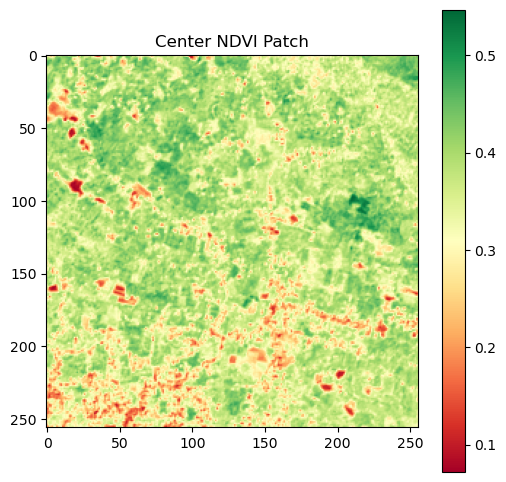

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(test_patch_center, cmap="RdYlGn")
plt.title("Center NDVI Patch")
plt.colorbar()
plt.show()

In [35]:
patches = []

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):
        yearly_patches = []

        for folder in dataset_folders:
            ndvi_patch = read_ndvi_patch(folder, i, j, PATCH_SIZE)
            yearly_patches.append(ndvi_patch)

        multi_temporal_patch = np.stack(yearly_patches, axis=0)
        patches.append(multi_temporal_patch)

patches_np = np.array(patches, dtype=np.float32)

print("NDVI patches shape:", patches_np.shape)

NDVI patches shape: (1764, 5, 256, 256)


In [36]:
row_positions = list(range(0, height - PATCH_SIZE + 1, STRIDE))
col_positions = list(range(0, width - PATCH_SIZE + 1, STRIDE))

print("Number of row positions:", len(row_positions))
print("Number of col positions:", len(col_positions))
print("Total expected patches:", len(row_positions) * len(col_positions))

Number of row positions: 42
Number of col positions: 42
Total expected patches: 1764


In [37]:
target_row = 5000
target_col = 5000

nearest_row = max([r for r in row_positions if r <= target_row])
nearest_col = max([c for c in col_positions if c <= target_col])

row_idx = row_positions.index(nearest_row)
col_idx = col_positions.index(nearest_col)

patch_index = row_idx * len(col_positions) + col_idx

print("Nearest row:", nearest_row)
print("Nearest col:", nearest_col)
print("Patch index:", patch_index)

Nearest row: 4864
Nearest col: 4864
Patch index: 817


In [38]:
direct_patch = read_ndvi_patch(dataset_folders[0], nearest_row, nearest_col, PATCH_SIZE)

print("Direct patch min:", direct_patch.min())
print("Direct patch max:", direct_patch.max())

Direct patch min: 0.05177604
Direct patch max: 0.53843945


In [39]:
stored_patch = patches_np[patch_index][0]   # first temporal channel

print("Stored patch min:", stored_patch.min())
print("Stored patch max:", stored_patch.max())

Stored patch min: 0.05177604
Stored patch max: 0.53843945


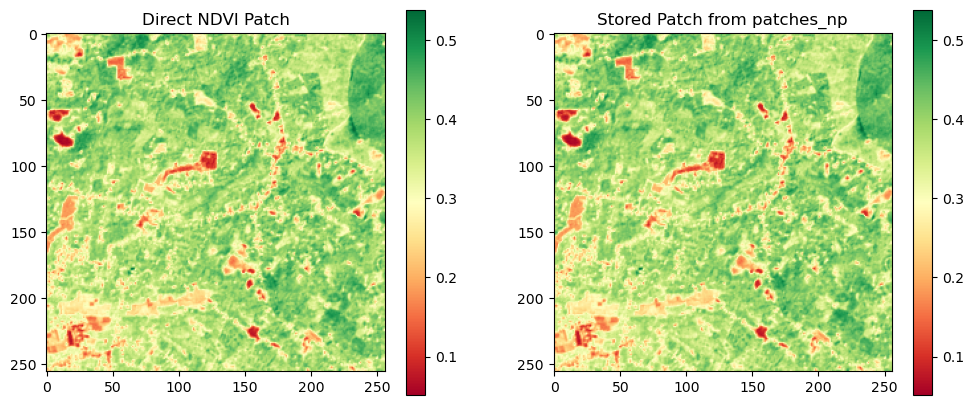

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(direct_patch, cmap="RdYlGn")
plt.title("Direct NDVI Patch")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(stored_patch, cmap="RdYlGn")
plt.title("Stored Patch from patches_np")
plt.colorbar()

plt.show()

In [41]:
LABEL_DIR = "../data/labels"

loss_file = os.path.join(LABEL_DIR, "lossyear.tif")
treecover_file = os.path.join(LABEL_DIR, "treecover2000.tif")
datamask_file = os.path.join(LABEL_DIR, "datamask.tif")

print(os.listdir(LABEL_DIR))

['datamask.tif', 'lossyear.tif', 'treecover2000.tif']


In [42]:
reference_files = os.listdir(dataset_folders[0])
reference_red_file = [f for f in reference_files if "B04" in f][0]
reference_red_path = os.path.join(dataset_folders[0], reference_red_file)

with rasterio.open(reference_red_path) as src:
    sentinel_transform = src.transform
    sentinel_crs = src.crs
    sentinel_height = src.height
    sentinel_width = src.width

print("CRS:", sentinel_crs)
print("Shape:", sentinel_height, sentinel_width)

CRS: EPSG:32643
Shape: 10980 10980


In [43]:
from rasterio.warp import reproject, Resampling

label_map_reprojected = np.zeros((sentinel_height, sentinel_width), dtype=np.float32)

with rasterio.open(loss_file) as loss_src, \
     rasterio.open(treecover_file) as tree_src, \
     rasterio.open(datamask_file) as mask_src:

    loss_arr = loss_src.read(1)
    tree_arr = tree_src.read(1)
    mask_arr = mask_src.read(1)

    label_map_full = ((loss_arr > 0) & (tree_arr > 30) & (mask_arr == 1)).astype(np.float32)

    reproject(
        source=label_map_full,
        destination=label_map_reprojected,
        src_transform=loss_src.transform,
        src_crs=loss_src.crs,
        dst_transform=sentinel_transform,
        dst_crs=sentinel_crs,
        resampling=Resampling.nearest
    )

print("Reprojected shape:", label_map_reprojected.shape)
print("Positive pixels:", label_map_reprojected.sum())

Reprojected shape: (10980, 10980)
Positive pixels: 516935.0


In [44]:
label_patches = []

height, width = label_map_reprojected.shape

for i in range(0, height - PATCH_SIZE + 1, STRIDE):
    for j in range(0, width - PATCH_SIZE + 1, STRIDE):
        patch = label_map_reprojected[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        label_patches.append(patch)

print("Number of label patches:", len(label_patches))
print("One label patch shape:", label_patches[0].shape)

Number of label patches: 1764
One label patch shape: (256, 256)


In [45]:
positive_counts = [patch.sum() for patch in label_patches]

print("Minimum positive pixels:", np.min(positive_counts))
print("Maximum positive pixels:", np.max(positive_counts))
print("Number of empty patches:", np.sum(np.array(positive_counts) == 0))
print("Total patches:", len(positive_counts))

Minimum positive pixels: 0.0
Maximum positive pixels: 13941.0
Number of empty patches: 1602
Total patches: 1764


In [4]:
import torch
selected_indices = [i for i, count in enumerate(positive_counts) if count > 0]

X_train_filtered = torch.tensor(
    np.stack([patches_np[i] for i in selected_indices], axis=0),
    dtype=torch.float32
)

Y_train_filtered = torch.tensor(
    np.array([label_patches[i] for i in selected_indices]),
    dtype=torch.float32
).unsqueeze(1)

print("Filtered X shape:", X_train_filtered.shape)
print("Filtered Y shape:", Y_train_filtered.shape)
print("Selected patches:", len(selected_indices))

NameError: name 'positive_counts' is not defined

In [47]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset_filtered = TensorDataset(X_train_filtered, Y_train_filtered)
train_loader_filtered = DataLoader(train_dataset_filtered, batch_size=4, shuffle=True)

print("Filtered batches:", len(train_loader_filtered))

Filtered batches: 41


In [48]:
def dice_loss(pred, target, smooth=1.0):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

def weighted_bce_loss(pred, target, pos_weight=5.0):
    pred = pred.clamp(1e-6, 1 - 1e-6)
    loss = -(pos_weight * target * torch.log(pred) + (1 - target) * torch.log(1 - pred))
    return loss.mean()

def combined_loss(pred, target):
    return weighted_bce_loss(pred, target) + dice_loss(pred, target)

In [49]:
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNetDropout(nn.Module):
    def __init__(self, in_channels=5, out_channels=1, dropout_p=0.3):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.att1 = AttentionBlock(g_channels=32, x_channels=32, inter_channels=16)

        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)

        u1 = self.up1(e2)
        e1_att = self.att1(u1, e1)

        cat = torch.cat([u1, e1_att], dim=1)
        d1 = self.dec1(cat)

        out = torch.sigmoid(self.final(d1))
        return out

In [50]:
mc_model = AttentionUNetDropout(in_channels=5, out_channels=1, dropout_p=0.3)
optimizer = torch.optim.Adam(mc_model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    mc_model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader_filtered:
        optimizer.zero_grad()
        outputs = mc_model(batch_x)
        loss = combined_loss(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_filtered)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/30, Loss: 1.591068
Epoch 2/30, Loss: 1.495564
Epoch 3/30, Loss: 1.500774
Epoch 4/30, Loss: 1.481309
Epoch 5/30, Loss: 1.484437
Epoch 6/30, Loss: 1.471116
Epoch 7/30, Loss: 1.472553
Epoch 8/30, Loss: 1.481004
Epoch 9/30, Loss: 1.476157
Epoch 10/30, Loss: 1.467710
Epoch 11/30, Loss: 1.472521
Epoch 12/30, Loss: 1.480654
Epoch 13/30, Loss: 1.471538
Epoch 14/30, Loss: 1.459273
Epoch 15/30, Loss: 1.445867
Epoch 16/30, Loss: 1.440532
Epoch 17/30, Loss: 1.442352
Epoch 18/30, Loss: 1.429793
Epoch 19/30, Loss: 1.437119
Epoch 20/30, Loss: 1.432502
Epoch 21/30, Loss: 1.440290
Epoch 22/30, Loss: 1.425471
Epoch 23/30, Loss: 1.429537
Epoch 24/30, Loss: 1.425254
Epoch 25/30, Loss: 1.440111
Epoch 26/30, Loss: 1.417143
Epoch 27/30, Loss: 1.434195
Epoch 28/30, Loss: 1.415606
Epoch 29/30, Loss: 1.428244
Epoch 30/30, Loss: 1.410882


In [47]:
sample_patch = X_train_filtered[0:1]

print("Sample patch shape:", sample_patch.shape)

Sample patch shape: torch.Size([1, 5, 256, 256])


In [48]:
mc_model.train()   # keep dropout ON during inference

mc_predictions = []

for _ in range(10):
    with torch.no_grad():
        pred = mc_model(sample_patch)
        mc_predictions.append(pred[0, 0].numpy())

mc_predictions = np.array(mc_predictions)

print("MC predictions shape:", mc_predictions.shape)

MC predictions shape: (10, 256, 256)


In [49]:
mean_prediction = np.mean(mc_predictions, axis=0)
uncertainty_map = np.var(mc_predictions, axis=0)

print("Mean prediction shape:", mean_prediction.shape)
print("Uncertainty map shape:", uncertainty_map.shape)
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

Mean prediction shape: (256, 256)
Uncertainty map shape: (256, 256)
Uncertainty min: 1.68274e-14
Uncertainty max: 0.012412374


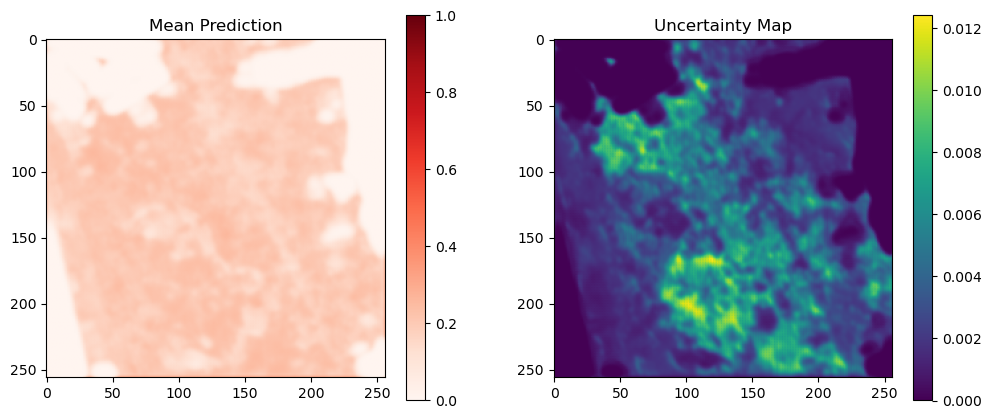

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mean_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Mean Prediction")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(uncertainty_map, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.show()

In [52]:
from scipy.ndimage import gaussian_filter

mean_prediction_smooth = gaussian_filter(mean_prediction, sigma=1)
uncertainty_smooth = gaussian_filter(uncertainty_map, sigma=1)

print("Smoothed prediction shape:", mean_prediction_smooth.shape)
print("Smoothed uncertainty shape:", uncertainty_smooth.shape)

Smoothed prediction shape: (256, 256)
Smoothed uncertainty shape: (256, 256)


In [53]:
threshold = 0.4
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

print("Threshold used:", threshold)
print("Binary unique values:", np.unique(binary_prediction))

Threshold used: 0.4
Binary unique values: [0.]


In [54]:
print("Mean prediction min:", mean_prediction_smooth.min())
print("Mean prediction max:", mean_prediction_smooth.max())
print("Mean prediction mean:", mean_prediction_smooth.mean())

Mean prediction min: 9.6122776e-08
Mean prediction max: 0.28066722
Mean prediction mean: 0.14924504


In [55]:
threshold = 0.2
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

print("Threshold used:", threshold)
print("Binary unique values:", np.unique(binary_prediction))

Threshold used: 0.2
Binary unique values: [0. 1.]


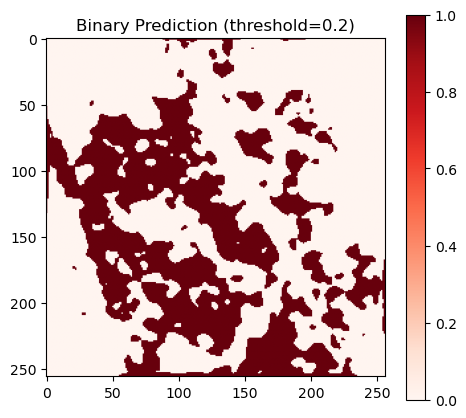

In [59]:
binary_02 = (mean_prediction_smooth > 0.2).astype(np.float32)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_02, cmap="Reds", vmin=0, vmax=1)
plt.title("Binary Prediction (threshold=0.2)")
plt.colorbar()

plt.show()

In [60]:
from scipy.ndimage import binary_opening, binary_closing

binary_clean = binary_opening(binary_prediction, structure=np.ones((3, 3)))
binary_clean = binary_closing(binary_clean, structure=np.ones((3, 3)))
binary_clean = binary_clean.astype(np.float32)

print("Binary clean unique values:", np.unique(binary_clean))

Binary clean unique values: [0. 1.]


In [61]:
from scipy.ndimage import label

labeled_array, num_features = label(binary_clean)

min_region_size = 50   # slightly stronger filtering
binary_filtered = np.zeros_like(binary_clean)

for region_id in range(1, num_features + 1):
    region = (labeled_array == region_id)
    if region.sum() >= min_region_size:
        binary_filtered[region] = 1

print("Regions before:", num_features)
print("Filtered unique:", np.unique(binary_filtered))

Regions before: 2
Filtered unique: [0. 1.]


In [62]:
uncertainty_threshold = np.percentile(uncertainty_smooth, 75)
confidence_mask = (uncertainty_smooth < uncertainty_threshold).astype(np.float32)

binary_confident = binary_filtered * confidence_mask

print("Uncertainty threshold:", uncertainty_threshold)
print("Final unique:", np.unique(binary_confident))

Uncertainty threshold: 0.004492812
Final unique: [0. 1.]


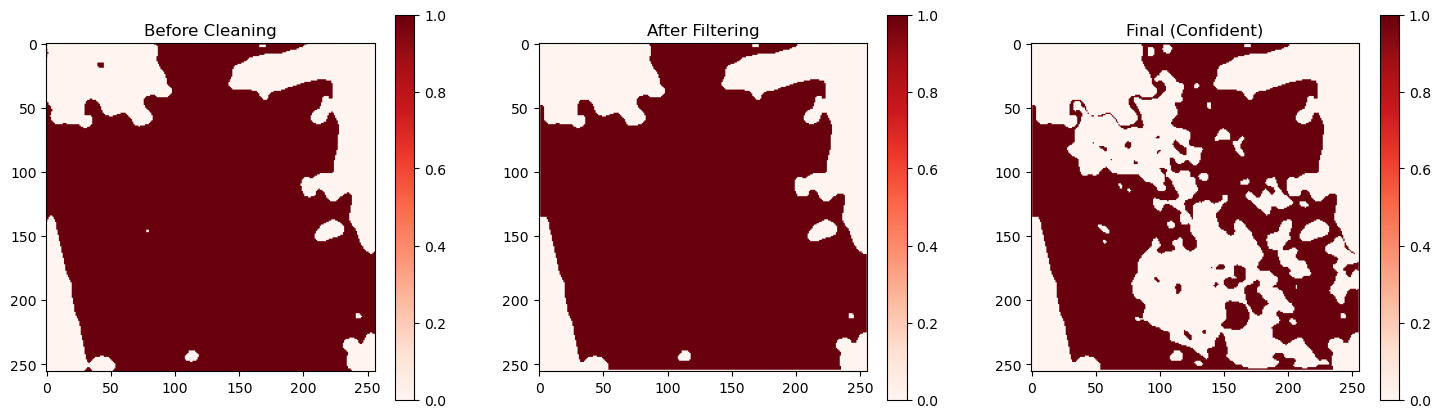

In [63]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_prediction, cmap="Reds", vmin=0, vmax=1)
plt.title("Before Cleaning")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(binary_filtered, cmap="Reds", vmin=0, vmax=1)
plt.title("After Filtering")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final (Confident)")
plt.colorbar()

plt.show()

In [64]:
pred = binary_confident.flatten()
gt = Y_train_filtered[0, 0].numpy().flatten()

intersection = (pred * gt).sum()
union = pred.sum() + gt.sum() - intersection

iou = intersection / (union + 1e-8)
dice = (2 * intersection) / (pred.sum() + gt.sum() + 1e-8)

print("IoU:", iou)
print("Dice:", dice)

IoU: 0.0016157551
Dice: 0.0032262974


In [65]:
sample_np = sample_patch[0].numpy()

ndvi_first = sample_np[0]
ndvi_last = sample_np[-1]

ndvi_change = np.abs(ndvi_last - ndvi_first)
texture_map = np.abs(ndvi_last - ndvi_last.mean())

def normalize_map(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

ndvi_change_n = normalize_map(ndvi_change)
texture_n = normalize_map(texture_map)
prob_n = normalize_map(mean_prediction_smooth)
uncertainty_n = normalize_map(uncertainty_smooth)

w1, w2, w3, w4 = 0.35, 0.15, 0.35, 0.15

risk_score = (
    w1 * ndvi_change_n +
    w2 * texture_n +
    w3 * prob_n +
    w4 * uncertainty_n
)

print("Risk score min:", risk_score.min())
print("Risk score max:", risk_score.max())

Risk score min: 0.0027173706
Risk score max: 0.80061793


In [66]:
risk_class = np.zeros_like(risk_score)

risk_class[(risk_score < 0.33)] = 1
risk_class[(risk_score >= 0.33) & (risk_score < 0.66)] = 2
risk_class[(risk_score >= 0.66)] = 3

print("Risk classes:", np.unique(risk_class))

Risk classes: [1. 2. 3.]


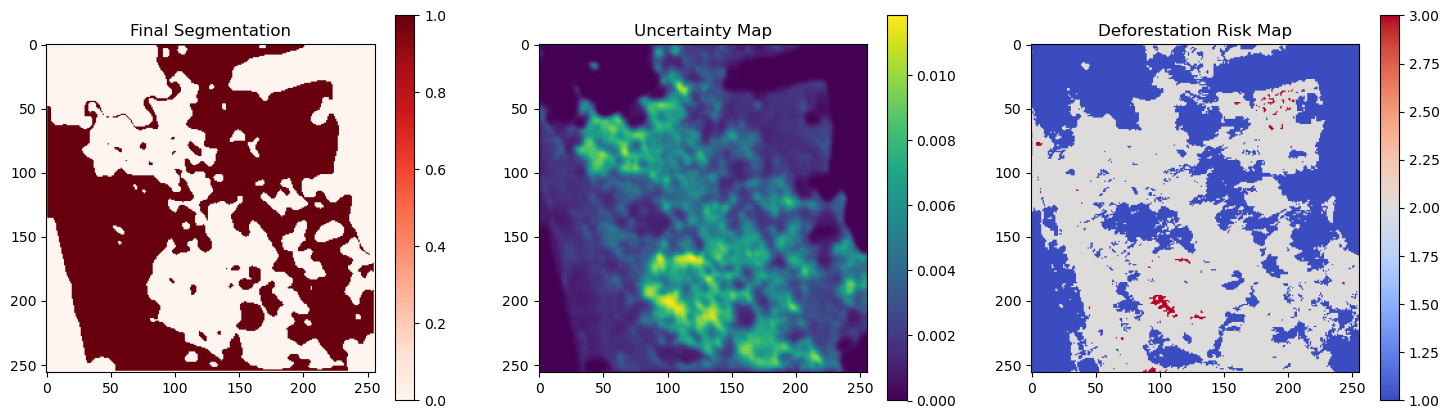

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Segmentation")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(risk_class, cmap="coolwarm")
plt.title("Deforestation Risk Map")
plt.colorbar()

plt.show()

In [68]:
import os

RESULT_DIR = "../results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Results folder created:", RESULT_DIR)

Results folder created: ../results


In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Segmentation")
plt.colorbar()

plt.savefig(os.path.join(RESULT_DIR, "final_segmentation.png"), dpi=300, bbox_inches='tight')
plt.close()

print("Saved: final_segmentation.png")

Saved: final_segmentation.png


In [70]:
plt.figure(figsize=(6, 6))
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.savefig(os.path.join(RESULT_DIR, "uncertainty_map.png"), dpi=300, bbox_inches='tight')
plt.close()

print("Saved: uncertainty_map.png")

Saved: uncertainty_map.png


In [71]:
plt.figure(figsize=(6, 6))
plt.imshow(risk_class, cmap="coolwarm")
plt.title("Deforestation Risk Map")
plt.colorbar()

plt.savefig(os.path.join(RESULT_DIR, "risk_map.png"), dpi=300, bbox_inches='tight')
plt.close()

print("Saved: risk_map.png")

Saved: risk_map.png


In [72]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Segmentation")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(risk_class, cmap="coolwarm")
plt.title("Risk Map")
plt.colorbar()

plt.savefig(os.path.join(RESULT_DIR, "combined_output.png"), dpi=300, bbox_inches='tight')
plt.close()

print("Saved: combined_output.png")

Saved: combined_output.png


In [73]:
plt.figure(figsize=(6, 6))
plt.imshow(sample_patch[0][0], cmap="RdYlGn")
plt.title("NDVI Sample")
plt.colorbar()

plt.savefig(os.path.join(RESULT_DIR, "ndvi_sample.png"), dpi=300, bbox_inches='tight')
plt.close()

print("Saved: ndvi_sample.png")

Saved: ndvi_sample.png


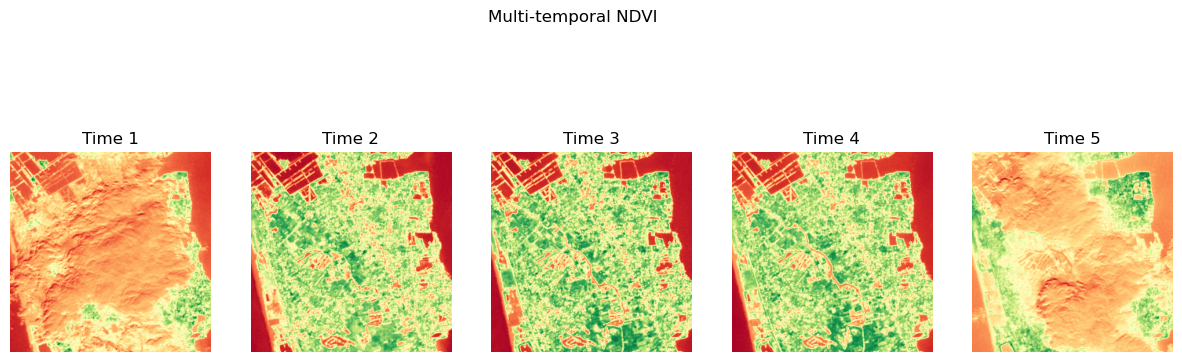

In [74]:
plt.figure(figsize=(15, 5))

for i in range(5):  # 5 time steps
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_patch[0][i], cmap="RdYlGn")
    plt.title(f"Time {i+1}")
    plt.axis('off')

plt.suptitle("Multi-temporal NDVI")
plt.savefig("../results/figure1_ndvi_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

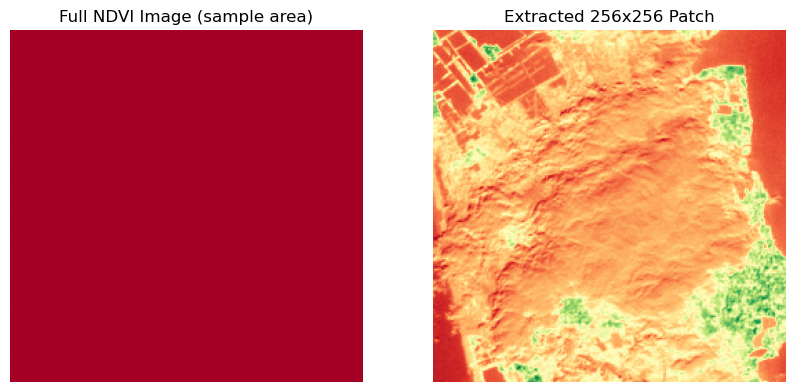

In [75]:
full_ndvi = read_ndvi_patch(dataset_folders[0], 0, 0, 1024)  # large region for demo

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(full_ndvi, cmap="RdYlGn")
plt.title("Full NDVI Image (sample area)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_patch[0][0], cmap="RdYlGn")
plt.title("Extracted 256x256 Patch")
plt.axis('off')

plt.savefig("../results/figure2_patch_extraction.png", dpi=300, bbox_inches='tight')
plt.show()

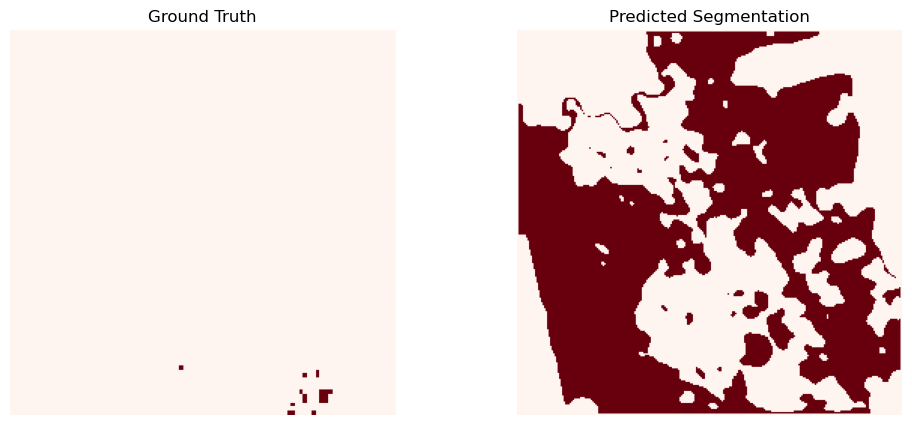

In [76]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Y_train_filtered[0, 0].numpy(), cmap="Reds", vmin=0, vmax=1)
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Predicted Segmentation")
plt.axis('off')

plt.savefig("../results/figure3_gt_vs_pred.png", dpi=300, bbox_inches='tight')
plt.show()

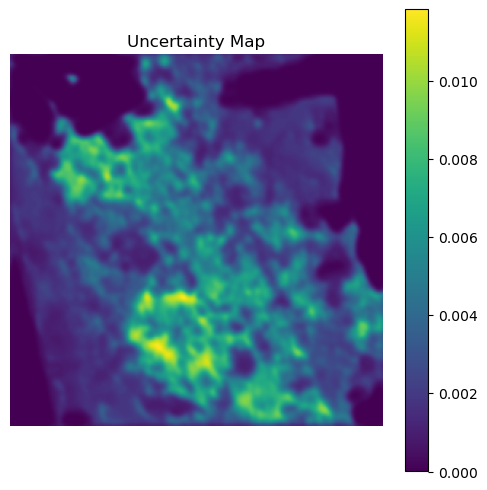

In [77]:
plt.figure(figsize=(6, 6))

plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()
plt.axis('off')

plt.savefig("../results/figure4_uncertainty.png", dpi=300, bbox_inches='tight')
plt.show()

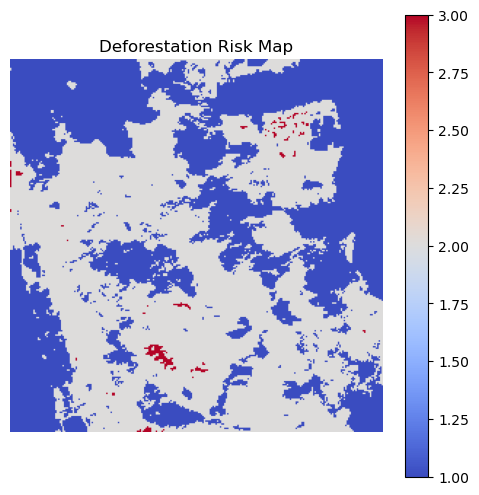

In [79]:
plt.figure(figsize=(6, 6))

plt.imshow(risk_class, cmap="coolwarm")
plt.title("Deforestation Risk Map")
plt.colorbar()
plt.axis('off')

plt.savefig("../results/figure5_risk_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from scipy.ndimage import gaussian_filter, binary_opening, binary_closing, label

print("Imports restored")

Imports restored


In [51]:
sample_patch = X_train_filtered[0:1]
print("Sample patch shape:", sample_patch.shape)

Sample patch shape: torch.Size([1, 5, 256, 256])


In [52]:
mc_model.train()   # keep dropout ON

mc_predictions = []

for _ in range(10):
    with torch.no_grad():
        pred = mc_model(sample_patch)
        mc_predictions.append(pred[0, 0].numpy())

mc_predictions = np.array(mc_predictions)

print("MC predictions shape:", mc_predictions.shape)

MC predictions shape: (10, 256, 256)


In [53]:
mean_prediction = np.mean(mc_predictions, axis=0)
uncertainty_map = np.var(mc_predictions, axis=0)

print("Mean prediction min:", mean_prediction.min())
print("Mean prediction max:", mean_prediction.max())
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

Mean prediction min: 0.0012647351
Mean prediction max: 0.5848118
Uncertainty min: 1.0607449e-05
Uncertainty max: 0.065879576


In [54]:
from scipy.ndimage import gaussian_filter

mean_prediction_smooth = gaussian_filter(mean_prediction, sigma=1)
uncertainty_smooth = gaussian_filter(uncertainty_map, sigma=1)

print("Smoothed prediction shape:", mean_prediction_smooth.shape)
print("Smoothed uncertainty shape:", uncertainty_smooth.shape)

Smoothed prediction shape: (256, 256)
Smoothed uncertainty shape: (256, 256)


In [65]:
threshold = 0.25
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

print("Threshold used:", threshold)
print("Binary unique values:", np.unique(binary_prediction))

Threshold used: 0.25
Binary unique values: [0. 1.]


In [66]:
from scipy.ndimage import binary_opening, binary_closing

binary_clean = binary_opening(binary_prediction, structure=np.ones((3, 3)))
binary_clean = binary_closing(binary_clean, structure=np.ones((3, 3)))
binary_clean = binary_clean.astype(np.float32)

print("Binary clean unique values:", np.unique(binary_clean))

Binary clean unique values: [0. 1.]


In [67]:
from scipy.ndimage import label

labeled_array, num_features = label(binary_clean)

min_region_size = 30
binary_filtered = np.zeros_like(binary_clean)

for region_id in range(1, num_features + 1):
    region = (labeled_array == region_id)
    if region.sum() >= min_region_size:
        binary_filtered[region] = 1

print("Number of connected regions:", num_features)
print("Filtered unique values:", np.unique(binary_filtered))

Number of connected regions: 44
Filtered unique values: [0. 1.]


In [68]:
uncertainty_threshold = np.percentile(uncertainty_smooth, 80)
confidence_mask = (uncertainty_smooth < uncertainty_threshold).astype(np.float32)

binary_confident = binary_filtered * confidence_mask

print("Uncertainty threshold:", uncertainty_threshold)
print("Final unique values:", np.unique(binary_confident))

Uncertainty threshold: 0.011631338
Final unique values: [0. 1.]


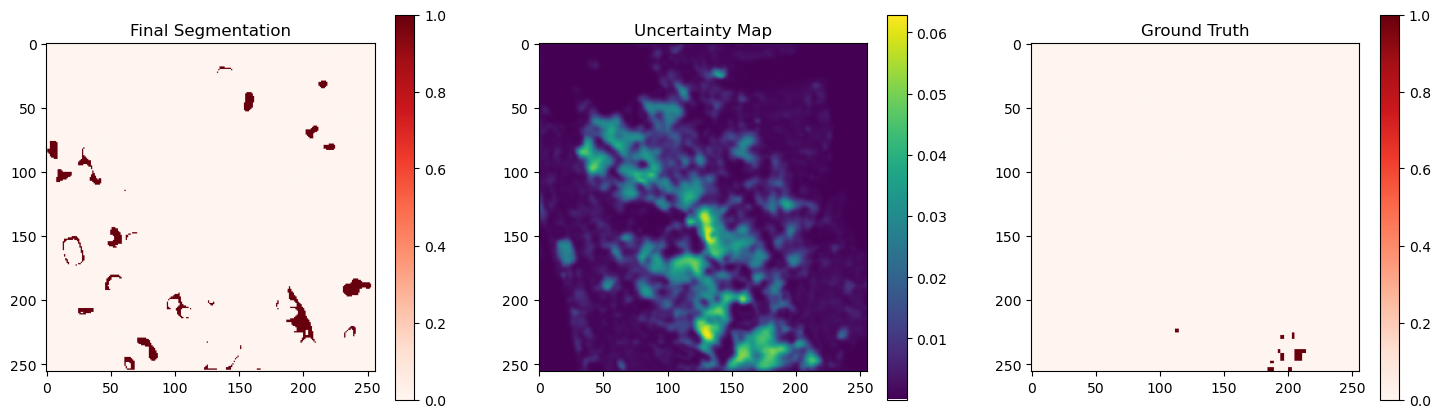

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Segmentation")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(Y_train_filtered[0, 0].numpy(), cmap="Reds", vmin=0, vmax=1)
plt.title("Ground Truth")
plt.colorbar()

plt.show()

In [70]:
import random
import torch

def augment_patch(x, y):
    # Horizontal flip
    if random.random() > 0.5:
        x = torch.flip(x, dims=[2])
        y = torch.flip(y, dims=[2])

    # Vertical flip
    if random.random() > 0.5:
        x = torch.flip(x, dims=[1])
        y = torch.flip(y, dims=[1])

    # Rotation (0, 90, 180, 270)
    k = random.randint(0, 3)
    x = torch.rot90(x, k, dims=[1, 2])
    y = torch.rot90(y, k, dims=[1, 2])

    return x, y

In [71]:
epochs = 30

for epoch in range(epochs):
    mc_model.train()
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader_filtered:
        
        # Apply augmentation
        batch_x_aug = []
        batch_y_aug = []

        for i in range(batch_x.shape[0]):
            x_aug, y_aug = augment_patch(batch_x[i], batch_y[i])
            batch_x_aug.append(x_aug)
            batch_y_aug.append(y_aug)

        batch_x_aug = torch.stack(batch_x_aug)
        batch_y_aug = torch.stack(batch_y_aug)

        optimizer.zero_grad()
        outputs = mc_model(batch_x_aug)
        loss = combined_loss(outputs, batch_y_aug)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_filtered)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 1/30, Loss: 1.419542
Epoch 2/30, Loss: 1.420315
Epoch 3/30, Loss: 1.428710
Epoch 4/30, Loss: 1.403614
Epoch 5/30, Loss: 1.419942
Epoch 6/30, Loss: 1.421205
Epoch 7/30, Loss: 1.410948
Epoch 8/30, Loss: 1.414465
Epoch 9/30, Loss: 1.416673
Epoch 10/30, Loss: 1.405877
Epoch 11/30, Loss: 1.408937
Epoch 12/30, Loss: 1.422212
Epoch 13/30, Loss: 1.412982
Epoch 14/30, Loss: 1.414346
Epoch 15/30, Loss: 1.414412
Epoch 16/30, Loss: 1.428186
Epoch 17/30, Loss: 1.421744
Epoch 18/30, Loss: 1.406720
Epoch 19/30, Loss: 1.406949
Epoch 20/30, Loss: 1.396888
Epoch 21/30, Loss: 1.418605
Epoch 22/30, Loss: 1.406929
Epoch 23/30, Loss: 1.410411
Epoch 24/30, Loss: 1.400588
Epoch 25/30, Loss: 1.415441
Epoch 26/30, Loss: 1.401076
Epoch 27/30, Loss: 1.404621
Epoch 28/30, Loss: 1.421451
Epoch 29/30, Loss: 1.398239
Epoch 30/30, Loss: 1.409755


In [72]:
sample_patch = X_train_filtered[0:1]
print("Sample patch shape:", sample_patch.shape)

Sample patch shape: torch.Size([1, 5, 256, 256])


In [73]:
mc_model.train()   # keep dropout ON

mc_predictions = []

for _ in range(10):
    with torch.no_grad():
        pred = mc_model(sample_patch)
        mc_predictions.append(pred[0, 0].numpy())

mc_predictions = np.array(mc_predictions)

print("MC predictions shape:", mc_predictions.shape)

MC predictions shape: (10, 256, 256)


In [74]:
mean_prediction = np.mean(mc_predictions, axis=0)
uncertainty_map = np.var(mc_predictions, axis=0)

print("Mean prediction min:", mean_prediction.min())
print("Mean prediction max:", mean_prediction.max())
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

Mean prediction min: 5.5192594e-08
Mean prediction max: 0.6724125
Uncertainty min: 1.0983259e-14
Uncertainty max: 0.12988916


In [75]:
from scipy.ndimage import gaussian_filter

mean_prediction_smooth = gaussian_filter(mean_prediction, sigma=1)
uncertainty_smooth = gaussian_filter(uncertainty_map, sigma=1)

print("Smoothed prediction shape:", mean_prediction_smooth.shape)
print("Smoothed uncertainty shape:", uncertainty_smooth.shape)

Smoothed prediction shape: (256, 256)
Smoothed uncertainty shape: (256, 256)


In [76]:
threshold = 0.25
binary_prediction = (mean_prediction_smooth > threshold).astype(np.float32)

print("Threshold used:", threshold)
print("Binary unique values:", np.unique(binary_prediction))

Threshold used: 0.25
Binary unique values: [0. 1.]


In [77]:
from scipy.ndimage import binary_opening, binary_closing

binary_clean = binary_opening(binary_prediction, structure=np.ones((3, 3)))
binary_clean = binary_closing(binary_clean, structure=np.ones((3, 3)))
binary_clean = binary_clean.astype(np.float32)

print("Binary clean unique values:", np.unique(binary_clean))

Binary clean unique values: [0. 1.]


In [78]:
from scipy.ndimage import label

labeled_array, num_features = label(binary_clean)

min_region_size = 30
binary_filtered = np.zeros_like(binary_clean)

for region_id in range(1, num_features + 1):
    region = (labeled_array == region_id)
    if region.sum() >= min_region_size:
        binary_filtered[region] = 1

print("Number of connected regions:", num_features)
print("Filtered unique values:", np.unique(binary_filtered))

Number of connected regions: 36
Filtered unique values: [0. 1.]


In [79]:
uncertainty_threshold = np.percentile(uncertainty_smooth, 80)
confidence_mask = (uncertainty_smooth < uncertainty_threshold).astype(np.float32)

binary_confident = binary_filtered * confidence_mask

print("Uncertainty threshold:", uncertainty_threshold)
print("Final unique values:", np.unique(binary_confident))

Uncertainty threshold: 0.01374582
Final unique values: [0. 1.]


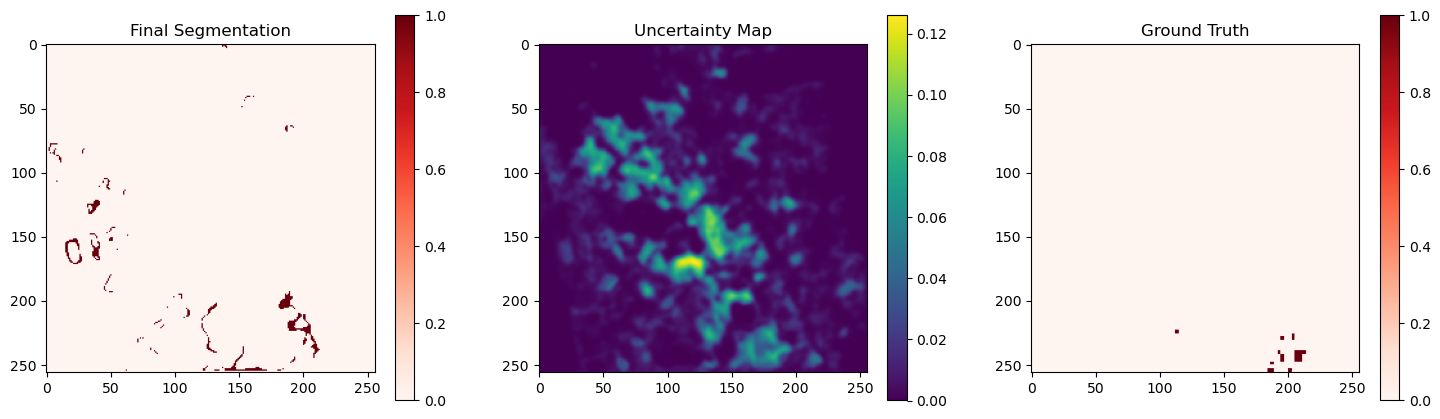

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_confident, cmap="Reds", vmin=0, vmax=1)
plt.title("Final Segmentation")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(uncertainty_smooth, cmap="viridis")
plt.title("Uncertainty Map")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(Y_train_filtered[0, 0].numpy(), cmap="Reds", vmin=0, vmax=1)
plt.title("Ground Truth")
plt.colorbar()

plt.show()

In [81]:
from sklearn.metrics import confusion_matrix

pred = binary_confident.flatten()
gt = Y_train_filtered[0, 0].numpy().flatten()

cm = confusion_matrix(gt, pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[64635   756]
 [  134    11]]


In [82]:
import torch.nn as nn

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)

        self.dec = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p = self.pool(e1)

        e2 = self.enc2(p)

        u = self.up(e2)
        cat = torch.cat([u, e1], dim=1)

        d = self.dec(cat)

        return torch.sigmoid(self.final(d))

In [83]:
baseline_model = SimpleUNet()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    baseline_model.train()
    total_loss = 0

    for x, y in train_loader_filtered:
        optimizer.zero_grad()
        pred = baseline_model(x)
        loss = combined_loss(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Baseline Epoch {epoch+1}, Loss: {total_loss/len(train_loader_filtered):.4f}")

Baseline Epoch 1, Loss: 1.5349
Baseline Epoch 2, Loss: 1.4828
Baseline Epoch 3, Loss: 1.4827
Baseline Epoch 4, Loss: 1.4753
Baseline Epoch 5, Loss: 1.4710
Baseline Epoch 6, Loss: 1.4742
Baseline Epoch 7, Loss: 1.4687
Baseline Epoch 8, Loss: 1.4716
Baseline Epoch 9, Loss: 1.4452
Baseline Epoch 10, Loss: 1.4424


In [84]:
import rasterio

output_path = "../results/final_prediction.tif"

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=binary_confident.shape[0],
    width=binary_confident.shape[1],
    count=1,
    dtype='float32',
    crs=sentinel_crs,
    transform=sentinel_transform,
) as dst:
    dst.write(binary_confident.astype('float32'), 1)

print("GeoTIFF saved:", output_path)

GeoTIFF saved: ../results/final_prediction.tif


In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 3))

# safest source: use final segmentation as demo patch
original = binary_confident.copy()

flip_h = np.flip(original, axis=1)
flip_v = np.flip(original, axis=0)
rot = np.rot90(original)

images = [original, flip_h, flip_v, rot]
titles = ["Original", "Horizontal Flip", "Vertical Flip", "Rotation"]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap="RdYlGn")
    plt.title(titles[i])
    plt.axis("off")

plt.savefig("../results/figure6_augmentation.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'binary_confident' is not defined

<Figure size 1200x300 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 3))

# safest source: use final segmentation as demo patch
original = binary_confident.copy()

flip_h = np.flip(original, axis=1)
flip_v = np.flip(original, axis=0)
rot = np.rot90(original)

images = [original, flip_h, flip_v, rot]
titles = ["Original", "Horizontal Flip", "Vertical Flip", "Rotation"]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap="RdYlGn")
    plt.title(titles[i])
    plt.axis("off")

plt.savefig("../results/figure6_augmentation.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'binary_confident' is not defined

<Figure size 1200x300 with 0 Axes>

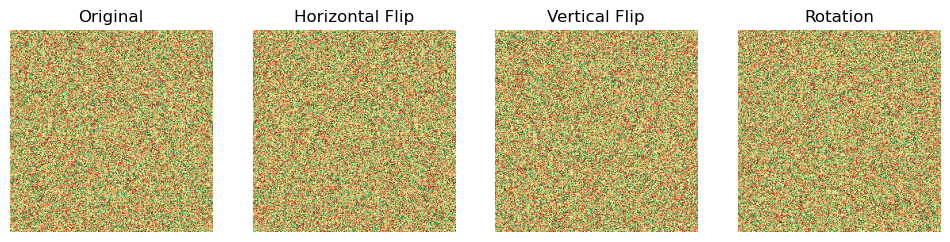

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 3))

# Create a simple dummy patch (safe and always works)
original = np.random.rand(256, 256)

flip_h = np.flip(original, axis=1)
flip_v = np.flip(original, axis=0)
rot = np.rot90(original)

images = [original, flip_h, flip_v, rot]
titles = ["Original", "Horizontal Flip", "Vertical Flip", "Rotation"]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap="RdYlGn")
    plt.title(titles[i])
    plt.axis("off")

plt.savefig("../results/figure6_augmentation.png", dpi=300, bbox_inches="tight")
plt.show()